# AlexNet Benchmark

use PY310, py311 not support torch.compile, py39 not support libnvrtc.so compatibility

In [1]:
model_name = "ResNet152"

import torch
from torch import nn
from torchvision import models
#import torch_mlir
import numpy as np
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll


In [2]:
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

## Prepare

In [3]:
#recompute, storeall = [
#    ragdoll.compile(x, "gpu", "input", "codegen", benchmark=True) for x in ["recompute.mlir", "storeall.mlir"]
#]
#recompute = ragdoll.compile("recompute.mlir", "gpu", "input", "codegen", benchmark=True)
#storeall = ragdoll.compile("storeall.mlir", "gpu", "input", "codegen", benchmark=True)
!iree-compile recompute.mlir \
-o recompute.vmfb \
--iree-hal-target-backends=cuda \
--iree-hal-cuda-llvm-target-arch=sm_86

!iree-compile storeall.mlir \
-o storeall.vmfb \
--iree-hal-target-backends=cuda \
--iree-hal-cuda-llvm-target-arch=sm_86
recompute = "recompute.vmfb"
storeall = "storeall.vmfb"

In [4]:
def load_executable(fb_file):
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    # replace compile with args of fatbin type
    # fb_file = ragdoll.compile(mlir, "gpu", "input", "codegen", benchmark=True)
    with open(fb_file, 'rb') as f:
        binary_data = f.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo

#recompute_fb, storeall_fb = [
#    load_executable(x) for x in [recompute, storeall]
#]
recompute_fb = load_executable("recompute.vmfb")
storeall_fb = load_executable("storeall.vmfb")

## Experimental

In [5]:
import torch
from torch import nn
from torchvision import models
import pandas as pd

MAGIC_NUM = 7777e-5

model = models.resnet152().train(False)
model.load_state_dict({k: torch.ones_like(v) * MAGIC_NUM for k, v in model.state_dict().items()})
model_dynamo = torch.compile(model, backend="inductor")

device = torch.device("cuda:0")
image = torch.randn(1, 3, 224, 224, requires_grad=True)
image = image.to(device)
model_native = model.to(device)

output_native = model_native(image)
output_dynamo = model_dynamo(image)
grad = torch.randn_like(output_native)

image_np = image.detach().cpu().numpy()
grad_np = grad.cpu().numpy()

df = pd.DataFrame()

### PyTorch (Baseline)

In [6]:
baseline_f = torch_model_benchmark(model_dynamo, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=17, 
                                 measure_count=11)
print('torch-dynamo-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output_dynamo, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=17, 
                                 measure_count=11)
print('torch-dynamo-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Dynamo")])
print(df)

torch-dynamo-gpu-forward:  [12.434140669510645, 12.402767260723254, 12.381133678204874, 12.38854492411894, 12.392709250835813, 12.386227464851212, 12.384929255965877, 12.386163915781415, 12.373989995788126, 12.38813645699445, 12.38609620315187]
12.391349006902407
torch-dynamo-gpu-backward:  [12.68137788728756, 12.673383907360188, 12.692017645082053, 12.682255521854934, 12.684937183033018, 12.689284213325557, 12.684068313854583, 12.697000166072565, 12.696882764644483, 12.679292765610358, 12.677564888316043]
12.685278659676486
        time      pass          item
0  12.391349   Forward  Torch Dynamo
0  12.685279  Backward  Torch Dynamo
0  25.076628      Full  Torch Dynamo


### Nabla without Optim

In [7]:
f1 = []
for i in range(11):
  f1 += [timeit("recompute_fb.forward(image_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', f1)
f1 = np.mean(f1)

f2 = ragdoll_model_benchmark(
    recompute,
    "forward",
    [(1, 3, 224, 224)], 
    device='gpu',
    warmups=2,
    repetitions=17, 
    measure_count=11)


print('ragdoll-opt1-gpu-forward in benchmark: ', f2)

f2 = np.mean(f2)

print(f1)
print(f2)

ragdoll-opt1-gpu-forward in timeit:  [0.4240569866755429, 0.4036151519154801, 0.4069550324450521, 0.40802959462299065, 0.4053130806149805, 0.40841571438838453, 0.4061451636473922, 0.4088705005672048, 0.4049509188489002, 0.40919646949452515, 0.407111384522389]
(1, 3, 224, 224)
['1x3x224x224xf32']
ragdoll-opt1-gpu-forward in benchmark:  [0.35000000000000003, 0.35100000000000003, 0.35100000000000003, 0.35100000000000003, 0.35100000000000003, 0.35100000000000003, 0.35100000000000003, 0.35100000000000003, 0.35100000000000003, 0.35100000000000003, 0.35100000000000003]
0.4084236361584402
0.35090909090909095


In [8]:
b1 = []
for i in range(11):
    b1 += [timeit("recompute_fb.dforward(grad_np)") /  17.0]
print('ragdoll-opt1-gpu-backward in timeit: ', b1)
# TODO(albert): unresolved value error
"""
b2 = ragdoll_model_benchmark(
    recompute,
    "dforward",
    [(1, 1000)],
    device='gpu',
    warmups=2,
    repetitions=17, 
    measure_count=11)
print(b2)
"""
df = pd.concat([df, get_dataframe(f2, np.mean(b1), "Nabla-opt1")])
print(df)

ragdoll-opt1-gpu-backward in timeit:  [1.830814174540779, 1.828075461637448, 1.8276327327989481, 1.8274878809118973, 1.8277524685596718, 1.8276670657317429, 1.8280499970869106, 1.8279416503056007, 1.8280795019339113, 1.834549640360124, 1.8342384756268824]
        time      pass          item
0  12.391349   Forward  Torch Dynamo
0  12.685279  Backward  Torch Dynamo
0  25.076628      Full  Torch Dynamo
0   0.350909   Forward    Nabla-opt1
0   1.829299  Backward    Nabla-opt1
0   2.180208      Full    Nabla-opt1


### Nabla with Optim

In [9]:
f1 = []
for i in range(11):
  f1 += [timeit("storeall_fb.forward(image_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', f1)
f1 = np.mean(f1)

f2 = ragdoll_model_benchmark(
    storeall,
    "forward",
    [(1, 3, 224, 224)], 
    device='gpu',
    warmups=2,
    repetitions=17, 
    measure_count=11)
print('ragdoll-opt1-gpu-forward in benchmark: ', f2)

b1 = []
for i in range(11):
    b1 += [timeit("storeall_fb.dforward(grad_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', b1)
b1 = np.mean(b1)


df = pd.concat([df, get_dataframe(np.mean(f2), b1, "Nabla-opt2")])
print(df)

ragdoll-opt1-gpu-forward in timeit:  [0.7391212228685617, 0.7395561587284593, 0.7394525852492627, 0.7395039602894994, 0.7395581862724879, 0.7396946009248495, 0.739595747059759, 0.7395983695545617, 0.7396291815401876, 0.7394327426000553, 0.7393177878111601]
(1, 3, 224, 224)
['1x3x224x224xf32']
ragdoll-opt1-gpu-forward in benchmark:  [0.706, 0.706, 0.706, 0.706, 0.706, 0.706, 0.706, 0.706, 0.706, 0.706, 0.706]
ragdoll-opt1-gpu-forward in timeit:  [1.5043340217979515, 1.5042531145188738, 1.5034091697238825, 1.502814836361829, 1.502701689982239, 1.5034740127842217, 1.5021942813387688, 1.5035286058178718, 1.5034263931653078, 1.5026194657034733, 1.504214078954914]
        time      pass          item
0  12.391349   Forward  Torch Dynamo
0  12.685279  Backward  Torch Dynamo
0  25.076628      Full  Torch Dynamo
0   0.350909   Forward    Nabla-opt1
0   1.829299  Backward    Nabla-opt1
0   2.180208      Full    Nabla-opt1
0   0.706000   Forward    Nabla-opt2
0   1.503361  Backward    Nabla-opt2


In [10]:
df.style.hide(axis="index")

time,pass,item
12.391349,Forward,Torch Dynamo
12.685279,Backward,Torch Dynamo
25.076628,Full,Torch Dynamo
0.350909,Forward,Nabla-opt1
1.829299,Backward,Nabla-opt1
2.180208,Full,Nabla-opt1
0.706000,Forward,Nabla-opt2
1.503361,Backward,Nabla-opt2
2.209361,Full,Nabla-opt2


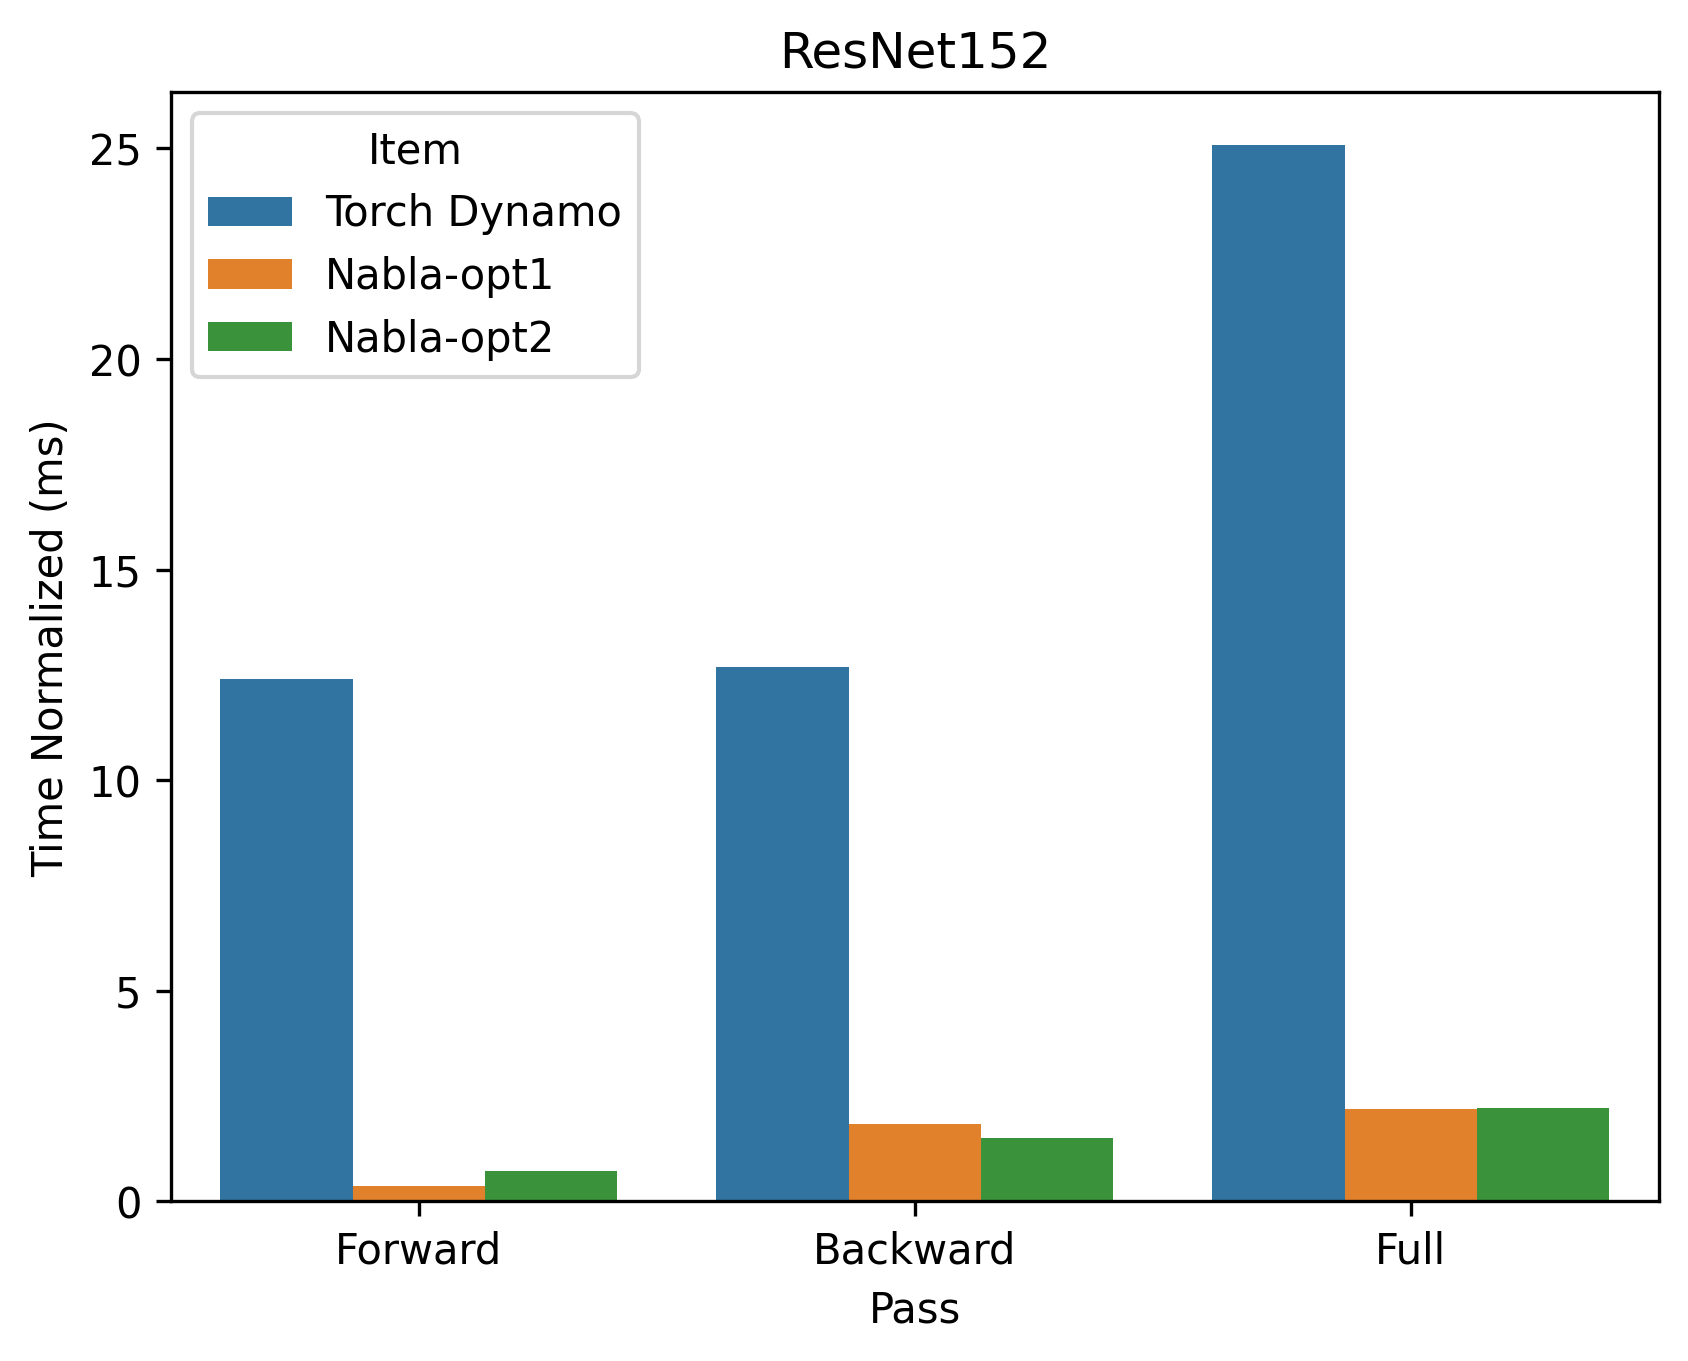

In [11]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [12]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,12.391349,Forward,Torch Dynamo,1.000000
0,0.350909,Forward,Nabla-opt1,35.312134
0,0.706000,Forward,Nabla-opt2,17.551486


In [13]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,12.685279,Backward,Torch Dynamo,1.000000
0,1.829299,Backward,Nabla-opt1,6.934503
0,1.503361,Backward,Nabla-opt2,8.437946


In [14]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,25.076628,Full,Torch Dynamo,1.000000
0,2.180208,Full,Nabla-opt1,11.501942
0,2.209361,Full,Nabla-opt2,11.350173


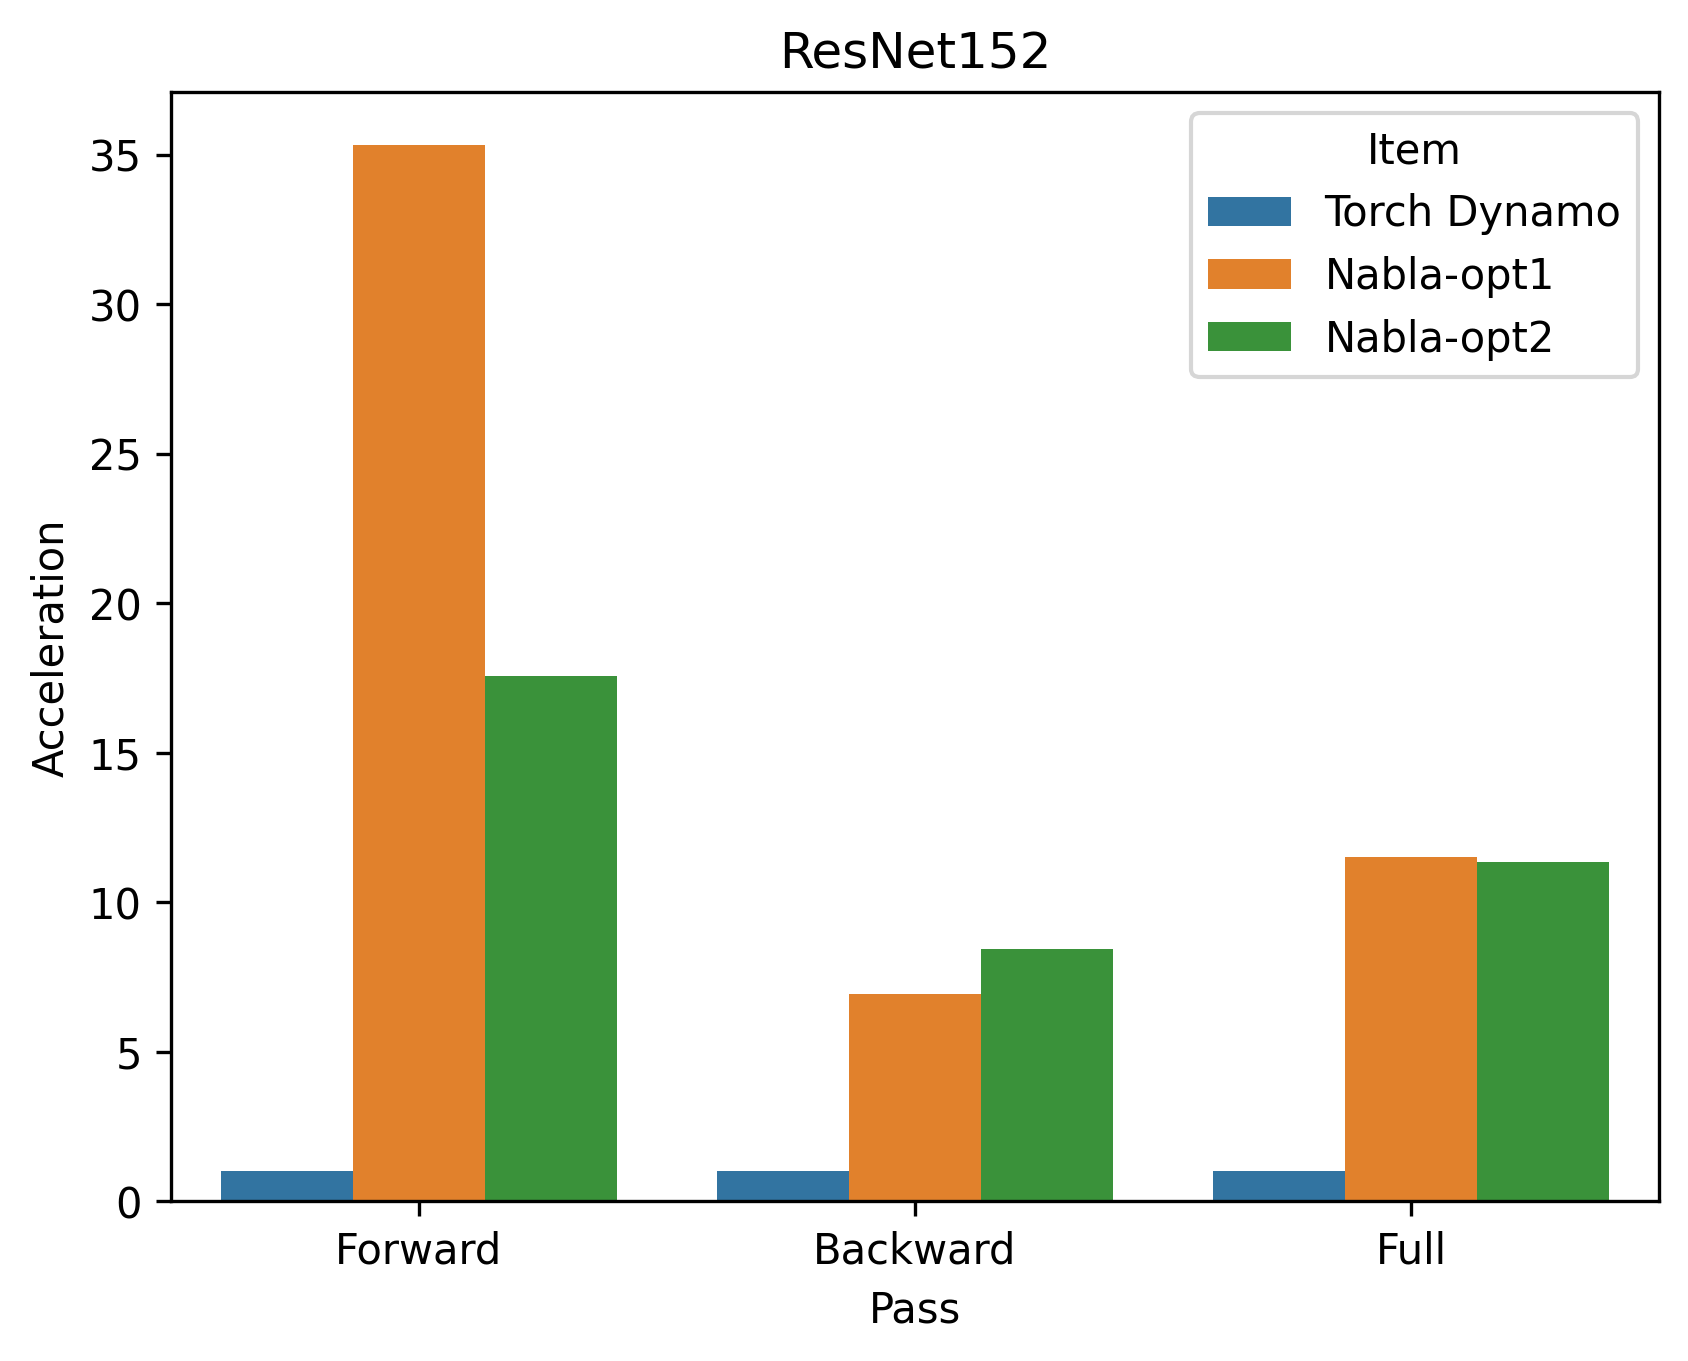

In [15]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")